In [6]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/naukri_data_science_jobs_india.csv")

print("Shape:", df.shape)
display(df.head())

Matplotlib is building the font cache; this may take a moment.


Shape: (12000, 5)


,Job_Role,Company,Location,Job Experience,Skills/Description
0,Senior Data Scientist,UPL,"Bangalore/Bengaluru, Mumbai (All Areas)",3-6,"python, MLT, statistical modeling, machine lea..."
1,Senior Data Scientist,Walmart,Bangalore/Bengaluru,5-9,"Data Science, Machine learning, Python, Azure,..."
2,Applied Data Scientist / ML Senior Engineer (P...,SAP India Pvt.Ltd,Bangalore/Bengaluru,5-10,"Python, IT Skills, Testing, Cloud, Product Man..."
3,Data Scientist,UPL,"Bangalore/Bengaluru, Mumbai (All Areas)",1-4,"python, machine learning, Data Science, data a..."
4,Data Scientist,Walmart,Bangalore/Bengaluru,4-8,"IT Skills, Python, Data Science, Machine Learn..."


In [3]:

print("shape:",df.shape)
print("datatypes:",df.dtypes)



shape: (12000, 5)
datatypes: Job_Role              str
Company               str
Location              str
Job Experience        str
Skills/Description    str
dtype: object


In [17]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.head(10)

,Job_Role,Company,Location,Job Experience,Skills/Description
0,Senior Data Scientist,UPL,"Bangalore/Bengaluru, Mumbai (All Areas)",3-6,"python, MLT, statistical modeling, machine lea..."
1,Senior Data Scientist,Walmart,Bangalore/Bengaluru,5-9,"Data Science, Machine learning, Python, Azure,..."
2,Applied Data Scientist / ML Senior Engineer (P...,SAP India Pvt.Ltd,Bangalore/Bengaluru,5-10,"Python, IT Skills, Testing, Cloud, Product Man..."
3,Data Scientist,UPL,"Bangalore/Bengaluru, Mumbai (All Areas)",1-4,"python, machine learning, Data Science, data a..."
4,Data Scientist,Walmart,Bangalore/Bengaluru,4-8,"IT Skills, Python, Data Science, Machine Learn..."
5,Principal Data Scientist,Walmart,Bangalore/Bengaluru,7-12,"Data Science, oral communication, Shell, Pytho..."
6,Data Scientist,Walmart,Bangalore/Bengaluru,4-8,"Computer science, cassandra, Machine learning,..."
7,Expert Data Scientist,UPL,"Bangalore/Bengaluru, Mumbai (All Areas)",6-9,"team lead, MLT, machine learning, aws, Python,..."
8,Data Scientist,Ericsson,Bangalore/Bengaluru,10-20,"Graphics, Bidding, Google Analytics, Data mana..."
9,Sr Data Scientist / Lead Data Scientist | Geak...,Geakminds Technologies Private Limited,Chennai,5-9,"Machine Learning, Python, Tableau, Azure, GCP,..."


In [27]:
print("JOB EXPERIENCE - 10 raw values")
print(df["Job Experience"].head(10).to_string(index=False))

print("\n" + "="*80)

print("SKILLS DESCRIPTION - 10 raw values")
for i, value in enumerate(df["Skills/Description"].head(10), 1):
    print(f"\n--- Row {i} ---")
    print(value)

JOB EXPERIENCE - 10 raw values
  3-6
  5-9
 5-10
  1-4
  4-8
 7-12
  4-8
  6-9
10-20
  5-9

SKILLS DESCRIPTION - 10 raw values

--- Row 1 ---
python, MLT, statistical modeling, machine learning, IT Skills, advanced analytics, scala, statistics

--- Row 2 ---
Data Science, Machine learning, Python, Azure, BiqQuery, GCP, PySpark, tensorflow

--- Row 3 ---
Python, IT Skills, Testing, Cloud, Product Management, SAP, Cloud computing, NLP

--- Row 4 ---
python, machine learning, Data Science, data analysis, aws, azure

--- Row 5 ---
IT Skills, Python, Data Science, Machine Learning, Big Data, Computer science, Computer vision, deep learning

--- Row 6 ---
Data Science, oral communication, Shell, Python, Unix, written, Big Data, machine learning

--- Row 7 ---
Computer science, cassandra, Machine learning, Agile, Data structures, Open source, Distribution system, Analytics

--- Row 8 ---
team lead, MLT, machine learning, aws, Python, IT Skills, Testing, Data Science

--- Row 9 ---
Graphics, B

In [34]:
print("Unique job_experience values:")
print(df["Job Experience"].dropna().unique())

print("\n"+"="*80)
print("\nNumber of unique values:")
print(df["Job Experience"].nunique())

Unique job_experience values:
<StringArray>
[            '3-6',             '5-9',            '5-10',             '1-4',
             '4-8',            '7-12',             '6-9',           '10-20',
             '2-7',             '2-4',
 ...
           '25-27', '17 May - 26 May',            '1-12',           '13-15',
             '2-9',           '14-17',           '20-30',           '11-13',
           '11-20',           '16-19']
Length: 143, dtype: str


Number of unique values:
143


In [39]:
print(df["Job Experience"].value_counts(dropna=False).head(50))

Job Experience
5-10     944
2-5      833
3-8      690
3-5      589
4-9      582
2-7      537
3-6      504
5-8      495
3-7      454
4-8      445
2-4      360
4-6      346
1-3      322
2-6      311
1-4      281
7-12     267
4-7      255
6-11     250
8-13     241
6-10     230
1-5      208
5-7      185
6-8      166
5-9      161
2-3      149
1-6      147
8-12     146
10-15    135
8-10     122
1-2      110
0-2      109
0-3       98
7-10      90
6-9       80
0-1       78
3-4       73
4-5       73
0-5       60
12-15     57
10-12     54
7-9       47
10-20     45
9-14      45
7-11      40
5-6       39
0-4       33
10-14     30
9-12      29
15-20     23
4-10      20
Name: count, dtype: int64


In [43]:
print("Missing job_experience:",
      df["Job Experience"].isna().sum())

print("Missing skills_description:",
      df["Skills/Description"].isna().sum())

print("Missing location:",
      df["Location"].isna().sum())

Missing job_experience: 0
Missing skills_description: 0
Missing location: 0


In [8]:
# Extract only proper numeric experience ranges
exp = df["Job Experience"].astype(str).str.extract(
    r"^\s*(\d+)\s*-\s*(\d+)\s*$"
)

df["min_exp"] = pd.to_numeric(exp[0], errors="coerce")
df["max_exp"] = pd.to_numeric(exp[1], errors="coerce")

# Check problematic values
print("Invalid/missing experience rows:")
display(df[df["min_exp"].isna()][["Job Experience"]])

print("Missing min_exp:", df["min_exp"].isna().sum())
print("Missing max_exp:", df["max_exp"].isna().sum())

Invalid/missing experience rows:


,Job Experience
1847,12 May - 21 May
2171,B.Tech/B.E.
3029,16 May - 22 May
7150,18 May
8681,12 May - 21 May
9535,17 May - 26 May
10498,18 May


Missing min_exp: 7
Missing max_exp: 7


In [9]:
df["exp_band"] = pd.cut(
    df["min_exp"],
    bins=[-np.inf, 2, 5, np.inf],
    labels=["0-2 yrs", "2-5 yrs", "5+ yrs"],
    right=False
)

df["exp_band"].value_counts()

exp_band
2-5 yrs    6287
5+ yrs     4225
0-2 yrs    1481
Name: count, dtype: int64

In [10]:
# Take first listed location
df["city"] = (
    df["Location"]
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
)

# Standardize city names
def clean_city(city):
    city = city.strip()
    c = city.lower()

    if "bangalore" in c or "bengaluru" in c:
        return "Bangalore"
    elif "hyderabad" in c:
        return "Hyderabad"
    elif "gurgaon" in c or "gurugram" in c:
        return "Gurgaon"
    elif "delhi" in c or "noida" in c:
        return "Delhi/NCR"
    elif "mumbai" in c:
        return "Mumbai"
    elif "pune" in c:
        return "Pune"
    elif "chennai" in c:
        return "Chennai"
    elif "kolkata" in c:
        return "Kolkata"
    elif "ahmedabad" in c:
        return "Ahmedabad"
    elif "remote" in c:
        return "Remote"
    else:
        return city

df["city"] = df["city"].apply(clean_city)

df["city"].value_counts().head(15)

city
Bangalore       3877
Hyderabad       1638
Pune            1465
Mumbai          1149
Gurgaon         1010
Delhi/NCR        889
Chennai          770
Kolkata          246
Remote           153
Ahmedabad        115
Kochi/Cochin      95
Mohali            52
Jaipur            49
Chandigarh        44
Indore            36
Name: count, dtype: int64

In [11]:
skills = [
    "python",
    "sql",
    "r",
    "excel",
    "tableau",
    "power bi",
    "machine learning",
    "deep learning",
    "nlp",
    "aws",
    "azure",
    "spark",
    "tensorflow",
    "communication",
    "statistics",
    "data science",
    "data analysis",
    "pyspark",
    "gcp",
    "scala"
]

In [12]:
skills_text = df["Skills/Description"].fillna("").str.lower()

for skill in skills:
    column_name = skill.replace(" ", "_")
    
    df[column_name] = skills_text.str.contains(
        rf"\b{re.escape(skill)}\b",
        regex=True,
        na=False
    ).astype(int)

## Analysis 1 : skill demand


In [13]:
skill_counts = pd.Series({
    skill: df[skill.replace(" ", "_")].sum()
    for skill in skills
}).sort_values(ascending=False)

display(skill_counts)

python              3201
sql                 2216
machine learning    1794
data analysis       1638
data science        1295
aws                 1138
spark               1077
azure               1018
communication        761
tableau              747
excel                702
scala                601
power bi             557
r                    496
pyspark              377
gcp                  292
deep learning        202
statistics           170
nlp                  154
tensorflow           104
dtype: int64

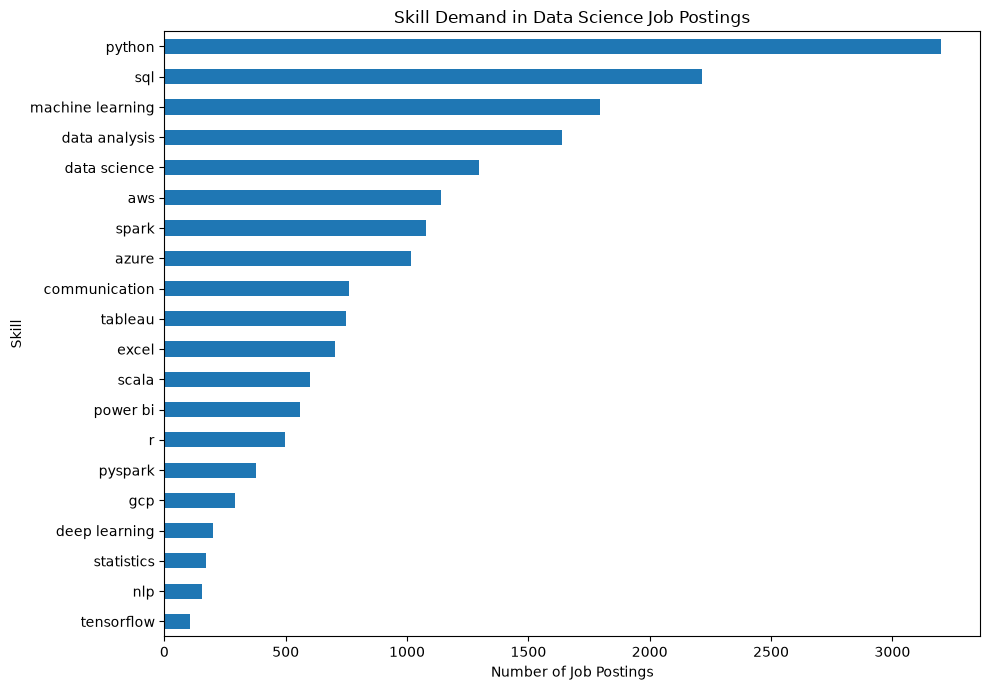

In [14]:
plt.figure(figsize=(10, 7))

skill_counts.sort_values().plot(kind="barh")

plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.title("Skill Demand in Data Science Job Postings")
plt.tight_layout()
plt.show()

## Analysis 2 — Skills vs experience

In [15]:
band_skill_counts = df.groupby(
    "exp_band",
    observed=False
)[[skill.replace(" ", "_") for skill in skills]].sum()

band_sizes = df.groupby(
    "exp_band",
    observed=False
).size()

band_skill_pct = band_skill_counts.div(
    band_sizes,
    axis=0
) * 100

display(band_skill_pct.round(2))

,python,sql,r,excel,tableau,power_bi,machine_learning,deep_learning,nlp,aws,azure,spark,tensorflow,communication,statistics,data_science,data_analysis,pyspark,gcp,scala
exp_band,,,,,,,,,,,,,,,,,,,,
0-2 yrs,21.07,15.26,5.06,14.99,6.41,3.71,12.63,2.09,1.01,4.46,3.17,4.52,0.74,8.31,1.76,9.59,22.69,0.95,0.74,1.96
2-5 yrs,26.75,19.41,4.10,6.11,6.19,4.85,14.68,1.57,1.38,9.37,7.43,9.61,0.91,6.55,1.46,9.61,14.62,3.47,2.53,5.23
5+ yrs,28.47,18.20,3.83,2.27,6.22,4.64,16.14,1.70,1.23,11.38,11.88,9.61,0.85,5.33,1.21,12.97,9.07,3.43,2.89,5.73


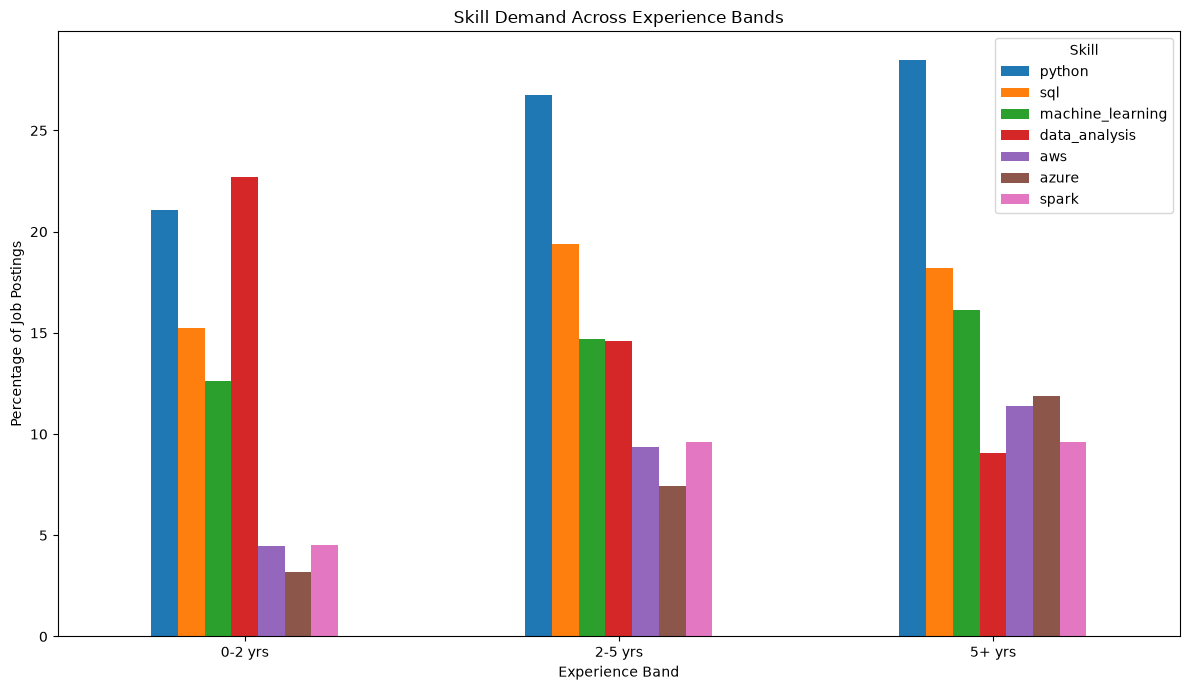

In [16]:
selected_skills = [
    "python",
    "sql",
    "machine_learning",
    "data_analysis",
    "aws",
    "azure",
    "spark"
]

band_skill_pct[selected_skills].plot(
    kind="bar",
    figsize=(12, 7)
)

plt.xlabel("Experience Band")
plt.ylabel("Percentage of Job Postings")
plt.title("Skill Demand Across Experience Bands")
plt.xticks(rotation=0)
plt.legend(title="Skill")
plt.tight_layout()
plt.show()

## Analysis 3 — City-based skill demand

In [17]:
major_cities = [
    "Bangalore",
    "Pune",
    "Hyderabad",
    "Mumbai",
    "Gurgaon",
    "Chennai",
    "Delhi/NCR"
]

city_df = df[df["city"].isin(major_cities)]

city_skill_counts = city_df.groupby("city")[
    [skill.replace(" ", "_") for skill in skills]
].sum()

city_sizes = city_df.groupby("city").size()

city_skill_pct = city_skill_counts.div(
    city_sizes,
    axis=0
) * 100

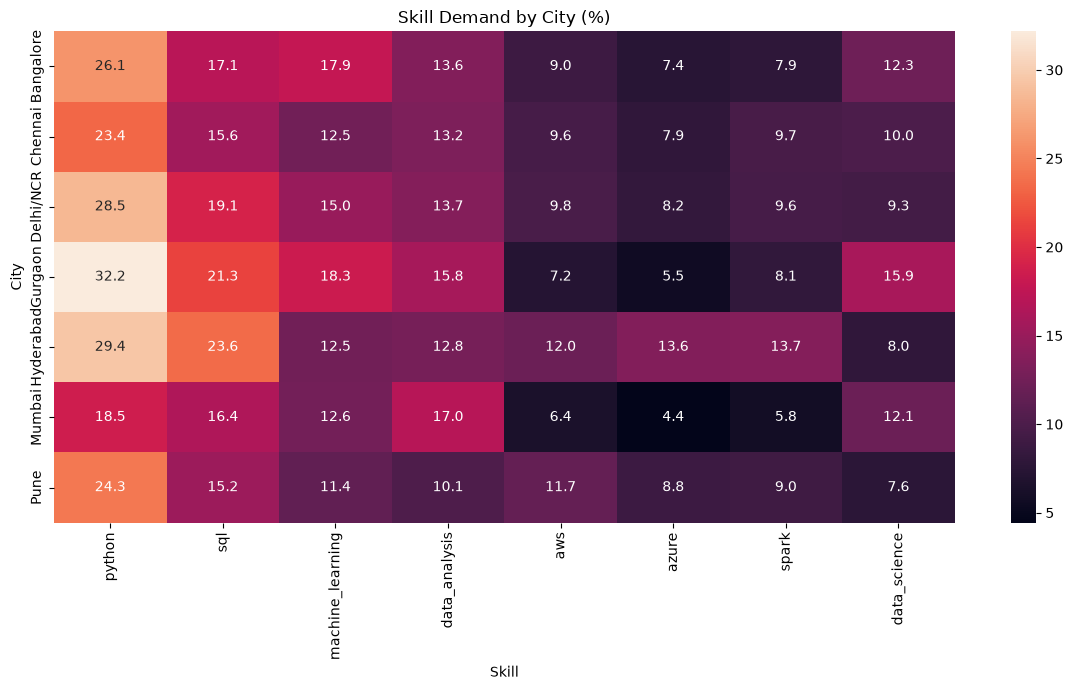

In [18]:
heatmap_skills = [
    "python",
    "sql",
    "machine_learning",
    "data_analysis",
    "aws",
    "azure",
    "spark",
    "data_science"
]

plt.figure(figsize=(12, 7))

sns.heatmap(
    city_skill_pct[heatmap_skills],
    annot=True,
    fmt=".1f"
)

plt.xlabel("Skill")
plt.ylabel("City")
plt.title("Skill Demand by City (%)")
plt.tight_layout()
plt.show()


## Analysis 4 — Boilerplate phrases

In [19]:
phrases = [
    "excellent communication",
    "team player",
    "problem solving",
    "problem-solving",
    "teamwork",
    "stakeholder management"
]

for phrase in phrases:
    column = "phrase_" + re.sub(
        r"[^a-z]+", "_", phrase
    ).strip("_")
    
    df[column] = skills_text.str.contains(
        re.escape(phrase),
        regex=True,
        na=False
    )
    
    print(
        phrase,
        "->",
        df[column].sum(),
        "postings"
    )

excellent communication -> 4 postings
team player -> 2 postings
problem solving -> 61 postings
problem-solving -> 7 postings
teamwork -> 0 postings
stakeholder management -> 54 postings


In [21]:
df.to_csv(
    "../data/processed/naukri_jobs_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
